# 1주차 코드과제
- **코드과제 1**: MNIST Digit Classification with CNN
- **코드과제 2**: Object Detection 실습 — YOLOv1 구현하기

---
# 코드과제 1

# MNIST Digit Classification with Convolutional Neural Network (CNN)

**Discipline(s):** Computer Vision, Deep Learning

colab에서 돌릴 경우, 런타임 유형을 GPU로 변경해주세요.

## 1. Import Statements

---



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

## 2. Data Preprocessing

---



The first step is to preprocess our data.

In [2]:
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.42MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


In [5]:
X_train = train_dataset.data
y_train = train_dataset.targets
X_test = test_dataset.data
y_test = test_dataset.targets

print("Training Images:", X_train.shape)  # [60000, 28, 28]
print("Testing Images:", X_test.shape)    # [10000, 28, 28]
print("Training Labels:", y_train.shape)  # [60000]
print("Test Labels:", y_test.shape)       # [10000]

Training Images: torch.Size([60000, 28, 28])
Testing Images: torch.Size([10000, 28, 28])
Training Labels: torch.Size([60000])
Test Labels: torch.Size([10000])


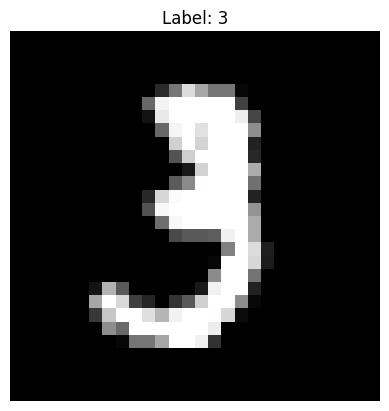

In [6]:
plt.imshow(X_train[10], cmap='gray')
plt.title(f"Label: {y_train[10].item()}")
plt.axis('off')
plt.show()

## 3. Convolutional Neural Network (CNN)

---



### 3.1. Define the Model

We then have to define our convolutional neural network.

In [7]:
# CNN 모델 정의 -> 차원이 어떻게 될지 생각하면서 코드 빈칸을 채워주세요.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            # activation function
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # 모델을 더 깊게 쌓아도 됩니다.

            # fully connected layer 전, flatten 과정 필요
            nn.Flatten(),

            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
# 모델 준비
model = SimpleCNN().to(DEVICE)

Once our model is defined, we can compile it using the Adam optimizer and the categorical cross-entropy loss function.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 3.2. Train the Model

In [10]:
def train(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (output.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [11]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            output = model(x)
            loss = criterion(output, y)

            total_loss += loss.item() * y.size(0)
            correct += (output.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [12]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

[Epoch 1] Train Loss: 0.1549, Train Acc: 0.9525 | Test Loss: 0.0702, Test Acc: 0.9775
[Epoch 2] Train Loss: 0.0558, Train Acc: 0.9825 | Test Loss: 0.0465, Test Acc: 0.9840
[Epoch 3] Train Loss: 0.0367, Train Acc: 0.9884 | Test Loss: 0.0496, Test Acc: 0.9837
[Epoch 4] Train Loss: 0.0248, Train Acc: 0.9920 | Test Loss: 0.0543, Test Acc: 0.9814
[Epoch 5] Train Loss: 0.0183, Train Acc: 0.9939 | Test Loss: 0.0484, Test Acc: 0.9862


### 3.3. 시각화

Finally, we can plot the curves.

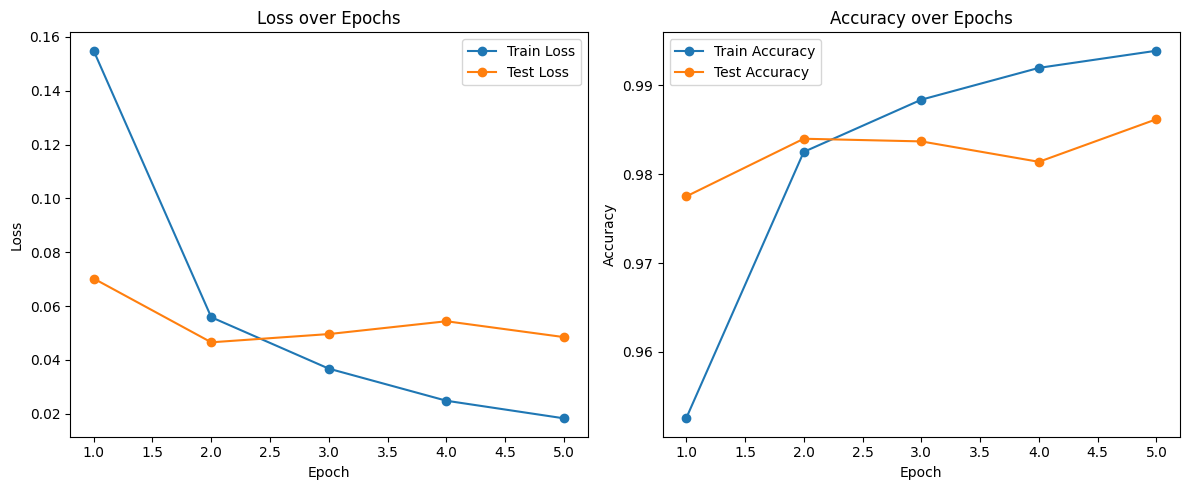

In [13]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

## 4. Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [14]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

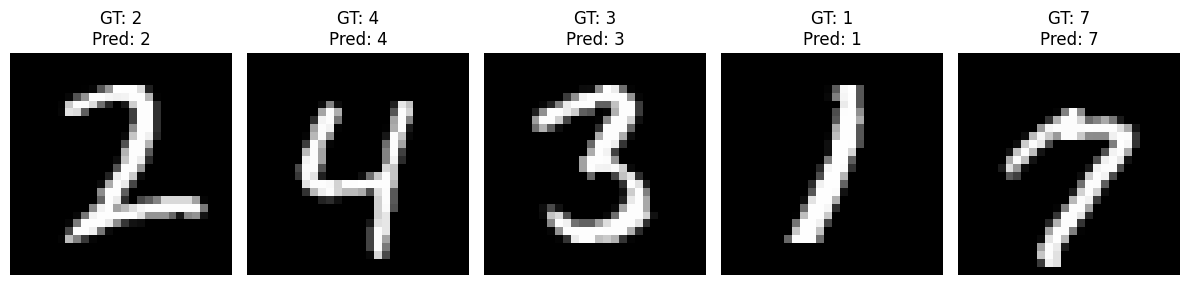

In [15]:
show_random_predictions(model, test_dataset, num_images=5)

## ResNet

In [16]:
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        # batch normalization
        self.bn1 = nn.BatchNorm2d(out_channels)

        # activation function
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 추가로 layer 등을 더 구현하셔도 됩니다.

        # Skip connection: 채널 수가 다르면 어떤 convolution layer를 사용하는게 좋을지 생각해주세요.
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=1,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        return self.relu(out)

In [18]:
class ResNetLike(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # layer 등을 추가로 더 쌓으셔도 됩니다.
        self.layer1 = ResidualBlock(16, 16)
        self.layer2 = ResidualBlock(16, 32)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 빈칸을 채워주세요.
        self.fc = nn.Linear(32, 10)

    def forward(self, x):
        # 빈칸을 채워주세요.
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [19]:
model = ResNetLike().to(DEVICE)

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [21]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

[Epoch 1] Train Loss: 0.4486, Train Acc: 0.9082 | Test Loss: 0.1504, Test Acc: 0.9585
[Epoch 2] Train Loss: 0.0853, Train Acc: 0.9787 | Test Loss: 0.0748, Test Acc: 0.9787
[Epoch 3] Train Loss: 0.0603, Train Acc: 0.9838 | Test Loss: 0.0641, Test Acc: 0.9810
[Epoch 4] Train Loss: 0.0485, Train Acc: 0.9859 | Test Loss: 0.0450, Test Acc: 0.9852
[Epoch 5] Train Loss: 0.0402, Train Acc: 0.9886 | Test Loss: 0.0403, Test Acc: 0.9877


### 시각화

Finally, we can plot the curves.

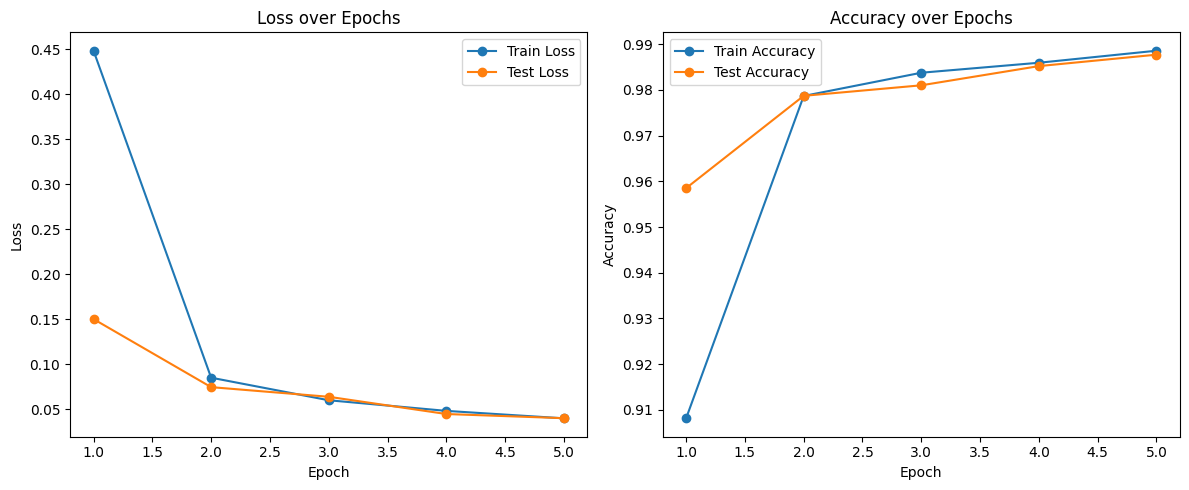

In [22]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

### Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [23]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

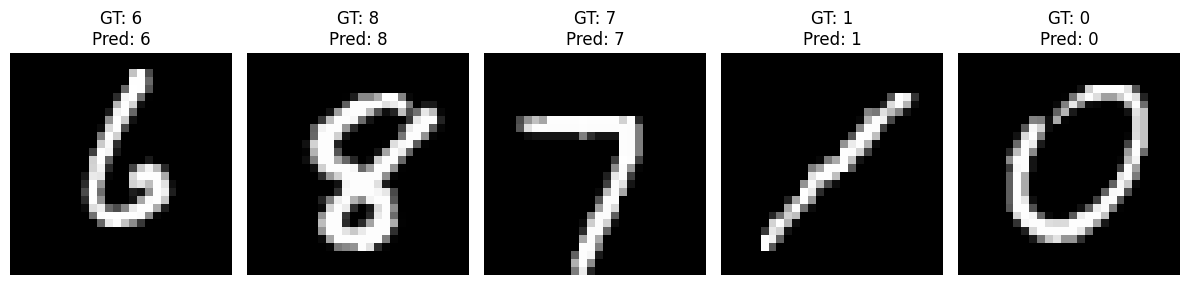

In [24]:
show_random_predictions(model, test_dataset, num_images=5)

# 다른 데이터셋으로도 진행해보기

In [25]:
# FashionMNIST 데이터셋으로 SimpleCNN과 ResNetLike 비교하기

# 1. 데이터 전처리
fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# 2. 데이터셋 불러오기
fashion_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=fashion_transform,
    download=True
)

fashion_test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=fashion_transform,
    download=True
)

# 3. DataLoader 만들기
fashion_train_loader = DataLoader(
    fashion_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

fashion_test_loader = DataLoader(
    fashion_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# FashionMNIST 클래스 이름
fashion_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("FashionMNIST Train:", len(fashion_train_dataset))
print("FashionMNIST Test :", len(fashion_test_dataset))
print("Image shape       :", fashion_train_dataset[0][0].shape)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.79MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.3MB/s]

FashionMNIST Train: 60000
FashionMNIST Test : 10000
Image shape       : torch.Size([1, 28, 28])


In [26]:
def train_fashion_model(model, train_loader, test_loader, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    for epoch in range(EPOCHS):
        # -------------------------
        # Training
        # -------------------------
        model.train()

        total_train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * labels.size(0)
            train_correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            train_total += labels.size(0)

        train_loss = total_train_loss / train_total
        train_accuracy = train_correct / train_total

        # -------------------------
        # Evaluation
        # -------------------------
        model.eval()

        total_test_loss = 0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                total_test_loss += loss.item() * labels.size(0)
                test_correct += (
                    outputs.argmax(dim=1) == labels
                ).sum().item()
                test_total += labels.size(0)

        test_loss = total_test_loss / test_total
        test_accuracy = test_correct / test_total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(
            f"[{model_name}] Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Test Loss: {test_loss:.4f}, "
            f"Test Acc: {test_accuracy:.4f}"
        )

    history = {
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "test_losses": test_losses,
        "test_accuracies": test_accuracies
    }

    return model, history

In [27]:
# 4. FashionMNIST에서 SimpleCNN 학습
fashion_cnn = SimpleCNN().to(DEVICE)

fashion_cnn, cnn_history = train_fashion_model(
    model=fashion_cnn,
    train_loader=fashion_train_loader,
    test_loader=fashion_test_loader,
    model_name="SimpleCNN"
)

[SimpleCNN] Epoch 1/5 | Train Loss: 0.3891, Train Acc: 0.8613 | Test Loss: 0.3216, Test Acc: 0.8824
[SimpleCNN] Epoch 2/5 | Train Loss: 0.2646, Train Acc: 0.9039 | Test Loss: 0.3110, Test Acc: 0.8861
[SimpleCNN] Epoch 3/5 | Train Loss: 0.2206, Train Acc: 0.9192 | Test Loss: 0.2693, Test Acc: 0.9037
[SimpleCNN] Epoch 4/5 | Train Loss: 0.1907, Train Acc: 0.9296 | Test Loss: 0.2580, Test Acc: 0.9094
[SimpleCNN] Epoch 5/5 | Train Loss: 0.1631, Train Acc: 0.9398 | Test Loss: 0.2680, Test Acc: 0.9086


In [28]:
# 5. FashionMNIST에서 ResNetLike 학습
fashion_resnet = ResNetLike().to(DEVICE)

fashion_resnet, resnet_history = train_fashion_model(
    model=fashion_resnet,
    train_loader=fashion_train_loader,
    test_loader=fashion_test_loader,
    model_name="ResNetLike"
)

[ResNetLike] Epoch 1/5 | Train Loss: 0.7364, Train Acc: 0.7518 | Test Loss: 0.5994, Test Acc: 0.7961
[ResNetLike] Epoch 2/5 | Train Loss: 0.4246, Train Acc: 0.8493 | Test Loss: 0.4658, Test Acc: 0.8347
[ResNetLike] Epoch 3/5 | Train Loss: 0.3577, Train Acc: 0.8723 | Test Loss: 0.4182, Test Acc: 0.8483
[ResNetLike] Epoch 4/5 | Train Loss: 0.3233, Train Acc: 0.8842 | Test Loss: 0.3591, Test Acc: 0.8714
[ResNetLike] Epoch 5/5 | Train Loss: 0.2999, Train Acc: 0.8918 | Test Loss: 0.3117, Test Acc: 0.8867


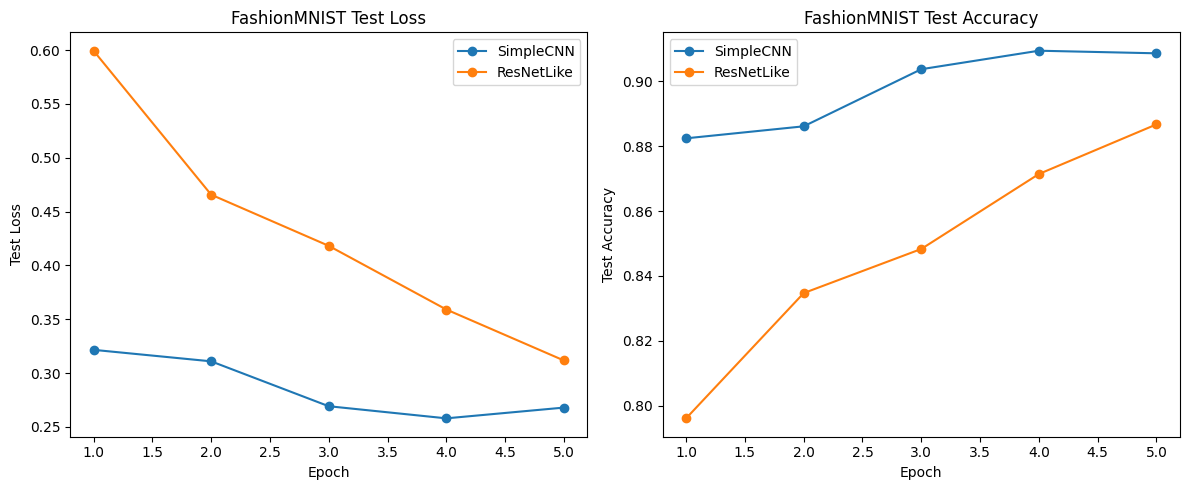

In [29]:
# 6. SimpleCNN과 ResNetLike의 성능 비교
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Test Loss 비교
plt.subplot(1, 2, 1)
plt.plot(
    epochs,
    cnn_history["test_losses"],
    marker="o",
    label="SimpleCNN"
)
plt.plot(
    epochs,
    resnet_history["test_losses"],
    marker="o",
    label="ResNetLike"
)
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("FashionMNIST Test Loss")
plt.legend()

# Test Accuracy 비교
plt.subplot(1, 2, 2)
plt.plot(
    epochs,
    cnn_history["test_accuracies"],
    marker="o",
    label="SimpleCNN"
)
plt.plot(
    epochs,
    resnet_history["test_accuracies"],
    marker="o",
    label="ResNetLike"
)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("FashionMNIST Test Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

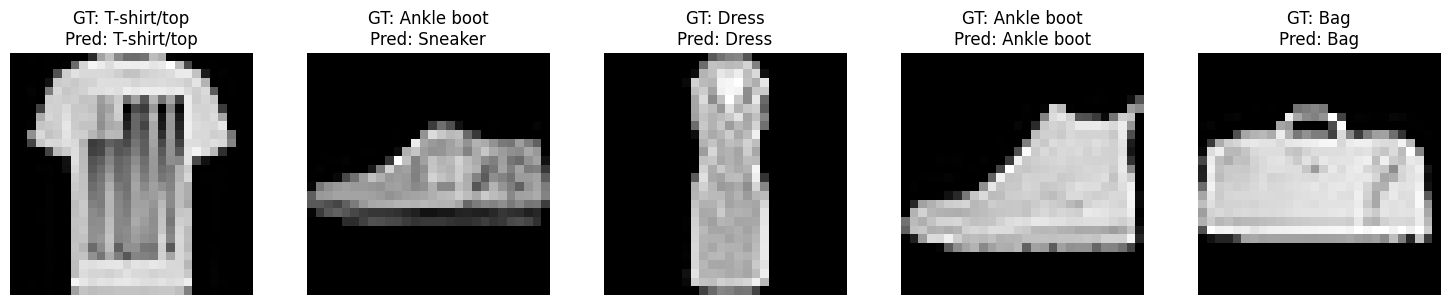

In [30]:
# 7. FashionMNIST 예측 결과 시각화
def show_fashion_predictions(
    model,
    dataset,
    class_names,
    num_images=5
):
    model.eval()

    indices = random.sample(
        range(len(dataset)),
        num_images
    )

    images = torch.stack([
        dataset[index][0]
        for index in indices
    ])

    labels = torch.tensor([
        dataset[index][1]
        for index in indices
    ])

    images = images.to(DEVICE)

    with torch.no_grad():
        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu()

    images = images.cpu()

    plt.figure(figsize=(15, 3))

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        plt.imshow(
            images[i].squeeze(),
            cmap="gray"
        )

        true_name = class_names[labels[i].item()]
        predicted_name = class_names[predictions[i].item()]

        plt.title(
            f"GT: {true_name}\n"
            f"Pred: {predicted_name}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_fashion_predictions(
    model=fashion_resnet,
    dataset=fashion_test_dataset,
    class_names=fashion_classes,
    num_images=5
)

---
# 코드과제 2

# [Week 2] Object Detection 실습 : YOLOv1 구현하기 (Assignment)

이번 과제는 **PascalVOC 데이터셋**을 사용하여 **YOLOv1** 모델을 밑바닥부터(Scratch) 구현해보는 것입니다.

**목표**:
1. YOLOv1의 **CNN 아키텍처**를 직접 구현합니다.
2. YOLOv1의 핵심인 **Loss Function** (Localization, Confidence, Class Probability)을 구현합니다.
3. PascalVOC 데이터셋으로 모델을 학습시키고 결과를 확인합니다.

**참고**:
- Colab에서 실행 시 **런타임 > 런타임 유형 변경 > 하드웨어 가속기**를 **GPU**로 설정해주세요.
---

In [31]:
## 1. Import Statements

import os, subprocess
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.transforms.functional as FT
from sklearn.model_selection import train_test_split

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. Data Preprocessing (PascalVOC)

Kaggle에서 PascalVOC 데이터셋을 다운로드합니다.

In [32]:
import kagglehub

# kagglehub가 데이터를 받아서 그 경로를 반환 (이동 불필요)
final_path = kagglehub.dataset_download("aladdinpersson/pascalvoc-yolo")
print("Data Path:", final_path)
print("폴더 내용:", os.listdir(final_path))   # images, labels, train.csv, test.csv 확인용

# 경로 설정
img_dir = os.path.join(final_path, "images")
label_dir = os.path.join(final_path, "labels")
total_train_csv = os.path.join(final_path, "train.csv")
test_csv = os.path.join(final_path, "test.csv")

# Train/Valid Split
df = pd.read_csv(total_train_csv)
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
train_df.to_csv("train.csv", index=False)
val_df.to_csv("valid.csv", index=False)
print("train:", len(train_df), "/ valid:", len(val_df))

100%|██████████| 4.31G/4.31G [04:14<00:00, 18.1MB/s]

Extracting files...


Data Path: /root/.cache/kagglehub/datasets/aladdinpersson/pascalvoc-yolo/versions/1
폴더 내용: ['100examples.csv', 'labels', 'get_data', 'generate_csv.py', 'test.csv', 'images', '8examples.csv', 'train.csv']
train: 14895 / valid: 1655


## 3. Model Implementation (YOLOv1)

YOLOv1의 아키텍처를 구현합니다. 논문에 나온 구조를 참고하여 `CNNBlock`과 `Yolov1` 클래스를 완성하세요.

### [TODO 1] YOLOv1 모델 구조 구현

In [33]:
# YOLOv1 Architecture Configuration
architecture_config = [
    (7, 64, 2, 3),  # (kernel_size, num_filters, stride, padding)
    "M",             # MaxPool
    (3, 192, 1, 1),
    "M",
    (1, 128, 1, 0),
    (3, 256, 1, 1),
    (1, 256, 1, 0),
    (3, 512, 1, 1),
    "M",
    [(1, 256, 1, 0), (3, 512, 1, 1), 4],  # [Tuple1, Tuple2, repeat]
    (1, 512, 1, 0),
    (3, 1024, 1, 1),
    "M",
    [(1, 512, 1, 0), (3, 1024, 1, 1), 2],
    (3, 1024, 1, 1),
    (3, 1024, 2, 1),
    (3, 1024, 1, 1),
    (3, 1024, 1, 1),
]


class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()

        # Conv2d -> BatchNorm2d -> LeakyReLU 순서
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            bias=False,
            **kwargs
        )

        self.batchnorm = nn.BatchNorm2d(out_channels)

        self.leakyrelu = nn.LeakyReLU(
            negative_slope=0.1
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.batchnorm(x)
        x = self.leakyrelu(x)

        return x


class Yolov1(nn.Module):
    def __init__(self, in_channels=3, **kwargs):
        super(Yolov1, self).__init__()

        self.architecture = architecture_config
        self.in_channels = in_channels

        # Darknet convolution layers
        self.darknet = self._create_conv_layers(
            self.architecture
        )

        # Fully connected layers
        self.fcs = self._create_fcs(**kwargs)

    def forward(self, x):
        # 1. Darknet 통과
        x = self.darknet(x)

        # 2. Flatten 및 3. FC layers 통과
        # Flatten은 self.fcs 내부의 nn.Flatten()에서 수행
        x = self.fcs(x)

        return x

    def _create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if isinstance(x, tuple):
                # x = (kernel_size, num_filters, stride, padding)
                kernel_size, out_channels, stride, padding = x

                layers.append(
                    CNNBlock(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        padding=padding
                    )
                )

                # 다음 convolution의 입력 채널 갱신
                in_channels = out_channels

            elif isinstance(x, str):
                # "M"은 2×2 Max Pooling
                layers.append(
                    nn.MaxPool2d(
                        kernel_size=2,
                        stride=2
                    )
                )

            elif isinstance(x, list):
                # x = [Tuple1, Tuple2, repeat]
                conv1 = x[0]
                conv2 = x[1]
                num_repeats = x[2]

                for _ in range(num_repeats):
                    # 첫 번째 convolution
                    layers.append(
                        CNNBlock(
                            in_channels=in_channels,
                            out_channels=conv1[1],
                            kernel_size=conv1[0],
                            stride=conv1[2],
                            padding=conv1[3]
                        )
                    )

                    # 두 번째 convolution
                    layers.append(
                        CNNBlock(
                            in_channels=conv1[1],
                            out_channels=conv2[1],
                            kernel_size=conv2[0],
                            stride=conv2[2],
                            padding=conv2[3]
                        )
                    )

                    # 두 convolution을 거친 뒤의 출력 채널
                    in_channels = conv2[1]

            else:
                raise TypeError(
                    f"지원하지 않는 architecture 항목입니다: {x}"
                )

        return nn.Sequential(*layers)

    def _create_fcs(self, split_size, num_boxes, num_classes):
        # S = grid 크기
        # B = 셀마다 예측하는 bounding box 개수
        # C = class 개수
        S = split_size
        B = num_boxes
        C = num_classes

        return nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                in_features=1024 * S * S,
                out_features=4096
            ),

            nn.LeakyReLU(
                negative_slope=0.1
            ),

            nn.Linear(
                in_features=4096,
                out_features=S * S * (C + B * 5)
            )
        )

## 4. Loss Function Implementation

YOLOv1 Loss는 5개의 부분으로 구성됩니다:
1. **Coordinate Loss** (Box Center x, y)
2. **Coordinate Loss** (Box Width, Height - Sqrt 적용)
3. **Object Confidence Loss** (객체가 있을 때)
4. **No Object Confidence Loss** (객체가 없을 때)
5. **Class Probability Loss**

### [TODO 2] YOLOv1 Loss 함수 구현

In [34]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YoloLoss, self).__init__()

        # YOLOv1은 각 손실 항에 제곱오차를 사용
        self.mse = nn.MSELoss(reduction="sum")

        self.S = S
        self.B = B
        self.C = C

        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        # predictions:
        # (batch_size, S*S*(C+B*5))
        # -> (batch_size, S, S, C+B*5)
        predictions = predictions.reshape(
            -1,
            self.S,
            self.S,
            self.C + self.B * 5
        )

        # ------------------------------------------------------
        # 1. IoU 계산 및 Responsible Box 찾기
        # ------------------------------------------------------

        # Box 1의 좌표: predictions[..., 21:25]
        iou_b1 = intersection_over_union(
            predictions[..., 21:25],
            target[..., 21:25]
        )

        # Box 2의 좌표: predictions[..., 26:30]
        iou_b2 = intersection_over_union(
            predictions[..., 26:30],
            target[..., 21:25]
        )

        # 두 IoU를 하나의 텐서로 합침
        # shape: (2, batch_size, S, S, 1)
        ious = torch.cat(
            [iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)],
            dim=0
        )

        # 각 셀에서 IoU가 더 큰 box 선택
        # bestbox = 0이면 Box 1, 1이면 Box 2
        iou_maxes, bestbox = torch.max(ious, dim=0)

        # 해당 셀에 객체가 존재하는지 나타내는 mask
        # target[..., 20]은 objectness
        exists_box = target[..., 20:21]

        # ------------------------------------------------------
        # 2. Box Coordinates Loss
        # ------------------------------------------------------

        # Responsible box의 좌표만 선택
        box_predictions = exists_box * (
            (1 - bestbox) * predictions[..., 21:25]
            + bestbox * predictions[..., 26:30]
        )

        # 정답 bounding box 좌표
        box_targets = exists_box * target[..., 21:25]

        # x, y는 그대로 사용
        pred_xy = box_predictions[..., 0:2]
        target_xy = box_targets[..., 0:2]

        # w, h에는 square root 적용
        # 예측값이 음수일 수 있으므로 sign과 abs를 사용
        pred_wh = torch.sign(
            box_predictions[..., 2:4]
        ) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4]) + 1e-6
        )

        target_wh = torch.sqrt(
            torch.clamp(box_targets[..., 2:4], min=0)
        )

        # 변환된 좌표 결합
        box_predictions = torch.cat(
            [pred_xy, pred_wh],
            dim=-1
        )

        box_targets = torch.cat(
            [target_xy, target_wh],
            dim=-1
        )

        # (batch, S, S, 4) -> (batch*S*S, 4)
        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2)
        )

        # ------------------------------------------------------
        # 3. Object Confidence Loss
        # ------------------------------------------------------

        # Responsible box의 confidence 선택
        # Box 1 confidence: index 20
        # Box 2 confidence: index 25
        pred_box_confidence = (
            (1 - bestbox) * predictions[..., 20:21]
            + bestbox * predictions[..., 25:26]
        )

        # 객체가 존재하는 셀에 대해서만 confidence loss 계산
        object_loss = self.mse(
            torch.flatten(
                exists_box * pred_box_confidence
            ),
            torch.flatten(
                exists_box * target[..., 20:21]
            )
        )

        # ------------------------------------------------------
        # 4. No Object Confidence Loss
        # ------------------------------------------------------

        # 객체가 없는 셀의 첫 번째 box confidence
        no_object_loss = self.mse(
            torch.flatten(
                (1 - exists_box) * predictions[..., 20:21],
                start_dim=1
            ),
            torch.flatten(
                (1 - exists_box) * target[..., 20:21],
                start_dim=1
            )
        )

        # 객체가 없는 셀의 두 번째 box confidence
        no_object_loss += self.mse(
            torch.flatten(
                (1 - exists_box) * predictions[..., 25:26],
                start_dim=1
            ),
            torch.flatten(
                (1 - exists_box) * target[..., 20:21],
                start_dim=1
            )
        )

        # ------------------------------------------------------
        # 5. Class Probability Loss
        # ------------------------------------------------------

        # 객체가 존재하는 셀에 대해서만 class loss 계산
        class_loss = self.mse(
            torch.flatten(
                exists_box * predictions[..., :20],
                end_dim=-2
            ),
            torch.flatten(
                exists_box * target[..., :20],
                end_dim=-2
            )
        )

        # ------------------------------------------------------
        # 최종 YOLOv1 Loss
        # ------------------------------------------------------

        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss

## 5. Utils (IoU, NMS, mAP)

Object Detection에 필요한 유틸리티 함수들입니다. (이미 구현되어 있음)

In [35]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    # ... (생략된 IoU 코드, 실제로는 이 셀에 전체 코드를 넣어야 함) ...
    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2
    elif box_format == "corners":
        box1_x1, box1_y1, box1_x2, box1_y2 = boxes_preds[..., 0:1], boxes_preds[..., 1:2], boxes_preds[..., 2:3], boxes_preds[..., 3:4]
        box2_x1, box2_y1, box2_x2, box2_y2 = boxes_labels[..., 0:1], boxes_labels[..., 1:2], boxes_labels[..., 2:3], boxes_labels[..., 3:4]

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = torch.abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = torch.abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

def non_max_suppression(bboxes, iou_threshold, threshold, box_format="midpoint"):
    assert type(bboxes) == list

    bboxes = [box for box in bboxes if box[1] > threshold]
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    bboxes_after_nms = []

    while bboxes:
        chosen_box = bboxes.pop(0)

        bboxes = [
            box
            for box in bboxes
            if box[0] != chosen_box[0]
            or intersection_over_union(
                torch.tensor(chosen_box[2:]),
                torch.tensor(box[2:]),
                box_format=box_format,
            )
            < iou_threshold
        ]

        bboxes_after_nms.append(chosen_box)

    return bboxes_after_nms

# mAP 함수 등 나머지 Utils는 생략 없이 포함되어야 하지만 지면 관계상 핵심만 보여드립니다.
def mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5, box_format="midpoint", num_classes=20):
    # ... (mAP 구현 코드) ...
    return 0.0 # Placeholder

## 6. Training Loop

모델을 학습시키는 Loop입니다.

In [36]:
class VOCDataset(Dataset):
    def __init__(
        self,
        csv_file,
        img_dir,
        label_dir,
        S=7,
        C=20,
        transform=None
    ):
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.S = S
        self.C = C
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # --------------------------------------------------
        # 1. 이미지와 라벨 파일 경로 가져오기
        # --------------------------------------------------
        image_filename = self.annotations.iloc[index, 0]
        label_filename = self.annotations.iloc[index, 1]

        image_path = os.path.join(
            self.img_dir,
            image_filename
        )
        label_path = os.path.join(
            self.label_dir,
            label_filename
        )

        # --------------------------------------------------
        # 2. 이미지 읽기
        # --------------------------------------------------
        image = Image.open(image_path).convert("RGB")

        # --------------------------------------------------
        # 3. YOLO 형식의 annotation 읽기
        #
        # 한 줄의 형식:
        # class_id x_center y_center width height
        # --------------------------------------------------
        boxes = []

        with open(label_path, "r") as f:
            for line in f.readlines():
                values = line.strip().split()

                # 빈 줄이나 잘못된 줄은 건너뜀
                if len(values) != 5:
                    continue

                class_label = int(float(values[0]))
                x = float(values[1])
                y = float(values[2])
                width = float(values[3])
                height = float(values[4])

                boxes.append(
                    [class_label, x, y, width, height]
                )

        # --------------------------------------------------
        # 4. 이미지 전처리
        #
        # bbox 좌표는 0~1로 정규화되어 있으므로
        # 이미지를 resize해도 좌표 자체는 바꿀 필요가 없음
        # --------------------------------------------------
        if self.transform is not None:
            image = self.transform(image)

        # --------------------------------------------------
        # 5. YOLO target tensor 생성
        #
        # shape: (S, S, C + 5)
        #       = (7, 7, 25)
        #
        # 0:C       : class one-hot vector
        # C         : objectness
        # C+1:C+5   : x, y, w, h
        # --------------------------------------------------
        label_matrix = torch.zeros(
            (self.S, self.S, self.C + 5),
            dtype=torch.float32
        )

        for box in boxes:
            class_label, x, y, width, height = box

            if not 0 <= class_label < self.C:
                raise ValueError(
                    f"잘못된 class id입니다: {class_label}"
                )

            # 객체 중심이 들어 있는 grid cell 위치
            # i: 행, j: 열
            i = min(self.S - 1, int(self.S * y))
            j = min(self.S - 1, int(self.S * x))

            # 전체 이미지 기준 좌표를
            # 해당 grid cell 내부 좌표로 변환
            x_cell = self.S * x - j
            y_cell = self.S * y - i

            # width와 height도 grid 단위로 변환
            width_cell = width * self.S
            height_cell = height * self.S

            # YOLOv1은 한 grid cell이 하나의 객체만 담당
            if label_matrix[i, j, self.C] == 0:
                # Objectness
                label_matrix[i, j, self.C] = 1

                # Bounding box
                label_matrix[
                    i,
                    j,
                    self.C + 1:self.C + 5
                ] = torch.tensor(
                    [
                        x_cell,
                        y_cell,
                        width_cell,
                        height_cell
                    ],
                    dtype=torch.float32
                )

                # Class one-hot encoding
                label_matrix[i, j, class_label] = 1

        return image, label_matrix


def train_fn(train_loader, model, optimizer, loss_fn):
    model.train()

    batch_losses = []

    loop = tqdm(
        train_loader,
        leave=True
    )

    for batch_idx, (images, targets) in enumerate(loop):
        images = images.to(device)
        targets = targets.to(device)

        # Forward pass
        predictions = model(images)
        loss = loss_fn(predictions, targets)

        # Backward pass
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

        loop.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    mean_loss = sum(batch_losses) / len(batch_losses)

    print(f"Mean training loss: {mean_loss:.4f}")

    return mean_loss


def main(
    num_epochs=5,
    batch_size=4
):
    # --------------------------------------------------
    # 이미지 전처리
    # --------------------------------------------------
    transform = transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.ToTensor()
    ])

    # --------------------------------------------------
    # Dataset
    # --------------------------------------------------
    train_dataset = VOCDataset(
        csv_file="train.csv",
        img_dir=img_dir,
        label_dir=label_dir,
        S=7,
        C=20,
        transform=transform
    )

    valid_dataset = VOCDataset(
        csv_file="valid.csv",
        img_dir=img_dir,
        label_dir=label_dir,
        S=7,
        C=20,
        transform=transform
    )

    # --------------------------------------------------
    # DataLoader
    # --------------------------------------------------
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=False
    )

    valid_loader = DataLoader(
        dataset=valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        drop_last=False
    )

    print(f"Train images: {len(train_dataset)}")
    print(f"Valid images: {len(valid_dataset)}")

    # --------------------------------------------------
    # Model, optimizer, loss
    # --------------------------------------------------
    model = Yolov1(
        split_size=7,
        num_boxes=2,
        num_classes=20
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=2e-5,
        weight_decay=0
    )

    loss_fn = YoloLoss(
        S=7,
        B=2,
        C=20
    )

    # --------------------------------------------------
    # Training loop
    # --------------------------------------------------
    train_history = []

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch + 1}/{num_epochs}]")

        mean_loss = train_fn(
            train_loader=train_loader,
            model=model,
            optimizer=optimizer,
            loss_fn=loss_fn
        )

        train_history.append(mean_loss)

    return model, train_history


if __name__ == "__main__":
    # 아래에서 데이터 확인 후 직접 main()을 실행
    pass

In [37]:
voc_transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor()
])

check_dataset = VOCDataset(
    csv_file="train.csv",
    img_dir=img_dir,
    label_dir=label_dir,
    S=7,
    C=20,
    transform=voc_transform
)

sample_image, sample_target = check_dataset[0]

print("Image shape :", sample_image.shape)
print("Target shape:", sample_target.shape)
print(
    "Number of assigned objects:",
    int(sample_target[..., 20].sum().item())
)

Image shape : torch.Size([3, 448, 448])
Target shape: torch.Size([7, 7, 25])
Number of assigned objects: 2


In [39]:
trained_model, train_history = main(
    num_epochs=3,
    batch_size=4
)

Train images: 14895
Valid images: 1655

Epoch [1/3]


  0%|          | 0/3724 [00:00<?, ?it/s]

Mean training loss: 49.2811

Epoch [2/3]


  0%|          | 0/3724 [00:00<?, ?it/s]

Mean training loss: 43.4976

Epoch [3/3]


  0%|          | 0/3724 [00:00<?, ?it/s]

Mean training loss: 41.1520
